# New Section

# 1.Setup & Load Data

In [54]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"

# cek semua file yang ada di folder
print("Isi folder:")
print(os.listdir(folder_path))

# load dataset hasil filtering
df = pd.read_csv(f"{folder_path}/dataset_hantavirus_mei_juni_2026.csv")
print(f"\nJumlah data: {len(df)}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Isi folder:
['dataset_tiktok_gabungan_final.csv', 'kamus_normalisasi.csv', 'inset_positif.csv', 'inset_negatif.csv', 'dataset_hantavirus_labeled.csv', 'distribusi_label_sentimen.png', 'tfidf_vectorizer.pkl', 'tfidf_matrix.npz', 'dataset_final_for_split.csv', 'train_test_split.pkl', 'hasil_prediksi.pkl', 'model_linearsvc.pkl', 'model_naivebayes.pkl', 'prediksi_linearsvc.pkl', 'prediksi_naivebayes.pkl', 'confusion_matrix_LinearSVC.png', 'confusion_matrix_Multinomial_Naive_Bayes.png', 'hasil_evaluasi.pkl', 'perbandingan_performa_model.png', 'perbandingan_performa_model.csv', 'dataset_hantavirus_mei_juni_2026.csv', 'dataset_hantavirus_preprocessed.csv', 'dataset_hantavirus_casefolding.csv', 'dataset_hantavirus_casefolding.gsheet', 'dataset_hantavirus_labeled.gsheet', 'dataset_hantavirus_normalization (1).gsheet', 'dataset_hantavirus_normalization.csv', 'dataset_h

,tanggal,nama_akun,teks
0,2026-05-05 04:18:23+00:00,aajuianbakk9,bisnis apa lagi ini
1,2026-05-05 03:11:33+00:00,firmandafahmis,libur berapa tahun lagi ini?
2,2026-05-05 04:34:11+00:00,fashionstudio_ai,project siapa lagi ini ??
3,2026-05-05 02:48:28+00:00,milavryn,Gua gak mau kek Covid lagi tolong 😭
4,2026-05-05 03:39:34+00:00,dempo20,klian percaya???


In [55]:
output_path = f"{folder_path}/dataset_hantavirus_preprocessed.csv"
df.to_csv(output_path, index=False)
print(f"Dataset hasil preprocessing disimpan di: {output_path}")

Dataset hasil preprocessing disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_preprocessed.csv


In [56]:
import os
folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"
print(os.listdir(folder_path))

['dataset_tiktok_gabungan_final.csv', 'kamus_normalisasi.csv', 'inset_positif.csv', 'inset_negatif.csv', 'dataset_hantavirus_labeled.csv', 'distribusi_label_sentimen.png', 'tfidf_vectorizer.pkl', 'tfidf_matrix.npz', 'dataset_final_for_split.csv', 'train_test_split.pkl', 'hasil_prediksi.pkl', 'model_linearsvc.pkl', 'model_naivebayes.pkl', 'prediksi_linearsvc.pkl', 'prediksi_naivebayes.pkl', 'confusion_matrix_LinearSVC.png', 'confusion_matrix_Multinomial_Naive_Bayes.png', 'hasil_evaluasi.pkl', 'perbandingan_performa_model.png', 'perbandingan_performa_model.csv', 'dataset_hantavirus_mei_juni_2026.csv', 'dataset_hantavirus_preprocessed.csv', 'dataset_hantavirus_casefolding.csv', 'dataset_hantavirus_casefolding.gsheet', 'dataset_hantavirus_labeled.gsheet', 'dataset_hantavirus_normalization (1).gsheet', 'dataset_hantavirus_normalization.csv', 'dataset_hantavirus_normalization.gsheet', 'dataset_hantavirus_tokenizing.csv', 'dataset_hantavirus_tokenizing.gsheet', 'dataset_cleaning.gsheet', 'dat

In [57]:
print("Hasil Keseluruhan Data" in os.listdir("/content/drive/MyDrive"))

True


# 2.Text Preprocessing

In [58]:
!pip install Sastrawi -q

## 2.1 Cleaning

In [59]:
import re
import string

def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "\U0001FA70-\U0001FAFF"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r"", text)

def cleaning(text):
    if not isinstance(text, str):
        return ""
    text = remove_emoji(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["teks"].apply(cleaning)
df[["teks", "text_clean"]].head(31)

,teks,text_clean
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini?,libur berapa tahun lagi ini
2,project siapa lagi ini ??,project siapa lagi ini
3,Gua gak mau kek Covid lagi tolong 😭,Gua gak mau kek Covid lagi tolong
4,klian percaya???,klian percaya
5,Singkat saja. Kapan mulai libur? Berapa tahun?,Singkat saja Kapan mulai libur Berapa tahun
6,jangan percaya yg namanya WHO,jangan percaya yg namanya WHO
7,To the point aja berapa tahun ?,To the point aja berapa tahun
8,udahla anj cape bgt cape,udahla anj cape bgt cape
9,saham apa yg bakal naik nih,saham apa yg bakal naik nih


In [60]:
import os

folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"

# Simpan hasil cleaning
df.to_csv(
    os.path.join(folder_path, "dataset_cleaning.csv"),
    index=False
)

print("Hasil cleaning berhasil disimpan di Google Drive.")

Hasil cleaning berhasil disimpan di Google Drive.


## 2.2 Case Folding

In [61]:
df = pd.read_csv(
    os.path.join(folder_path, "dataset_cleaning.csv")
)

df["text_clean"] = df["text_clean"].fillna("")

In [62]:
def case_folding(text):
    return text.lower()

df["text_casefolding"] = df["text_clean"].apply(case_folding)

df[["text_clean", "text_casefolding"]].head(31)

,text_clean,text_casefolding
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini,libur berapa tahun lagi ini
2,project siapa lagi ini,project siapa lagi ini
3,Gua gak mau kek Covid lagi tolong,gua gak mau kek covid lagi tolong
4,klian percaya,klian percaya
5,Singkat saja Kapan mulai libur Berapa tahun,singkat saja kapan mulai libur berapa tahun
6,jangan percaya yg namanya WHO,jangan percaya yg namanya who
7,To the point aja berapa tahun,to the point aja berapa tahun
8,udahla anj cape bgt cape,udahla anj cape bgt cape
9,saham apa yg bakal naik nih,saham apa yg bakal naik nih


In [63]:
output_path = f"{folder_path}/dataset_hantavirus_casefolding.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil case folding disimpan di: {output_path}")

Dataset hasil case folding disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_casefolding.csv


## 2.3 Normalization

In [64]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_casefolding.csv"
)

df["text_casefolding"] = df["text_casefolding"].fillna("")

In [65]:
kamus_df = pd.read_csv(
    f"{folder_path}/kamus_normalisasi.csv"
)

kamus_normalisasi = dict(
    zip(kamus_df["slang"], kamus_df["formal"])
)

print(f"Jumlah pasangan kata di kamus: {len(kamus_normalisasi)}")

Jumlah pasangan kata di kamus: 4331


In [66]:
def normalisasi(text):
    words = text.split()
    words = [kamus_normalisasi.get(word, word) for word in words]
    return " ".join(words)

df["text_normalization"] = df["text_casefolding"].apply(normalisasi)

df[["text_casefolding", "text_normalization"]].head(10)

,text_casefolding,text_normalization
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini,libur berapa tahun lagi ini
2,project siapa lagi ini,project siapa lagi ini
3,gua gak mau kek covid lagi tolong,gua enggak mau kayak covid lagi tolong
4,klian percaya,kalian percaya
5,singkat saja kapan mulai libur berapa tahun,singkat saja kapan mulai libur berapa tahun
6,jangan percaya yg namanya who,jangan percaya yang namanya who
7,to the point aja berapa tahun,tapi the point saja berapa tahun
8,udahla anj cape bgt cape,udahla anjing capek banget capek
9,saham apa yg bakal naik nih,saham apa yang bakal naik nih


In [67]:
output_path = f"{folder_path}/dataset_hantavirus_normalization.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil normalisasi disimpan di: {output_path}")

Dataset hasil normalisasi disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_normalization.csv


## 2.4 Tokenizing

In [ ]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_normalization.csv"
)

df["text_normalization"] = df["text_normalization"].fillna("")

In [69]:
df["text_token"] = df["text_normalization"].apply(lambda x: x.split())

df[["text_normalization", "text_token"]].head(10)

,text_normalization,text_token
0,bisnis apa lagi ini,"[bisnis, apa, lagi, ini]"
1,libur berapa tahun lagi ini,"[libur, berapa, tahun, lagi, ini]"
2,project siapa lagi ini,"[project, siapa, lagi, ini]"
3,gua enggak mau kayak covid lagi tolong,"[gua, enggak, mau, kayak, covid, lagi, tolong]"
4,kalian percaya,"[kalian, percaya]"
5,singkat saja kapan mulai libur berapa tahun,"[singkat, saja, kapan, mulai, libur, berapa, t..."
6,jangan percaya yang namanya who,"[jangan, percaya, yang, namanya, who]"
7,tapi the point saja berapa tahun,"[tapi, the, point, saja, berapa, tahun]"
8,udahla anjing capek banget capek,"[udahla, anjing, capek, banget, capek]"
9,saham apa yang bakal naik nih,"[saham, apa, yang, bakal, naik, nih]"


In [70]:
output_path = f"{folder_path}/dataset_hantavirus_tokenizing.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil tokenizing disimpan di: {output_path}")

Dataset hasil tokenizing disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_tokenizing.csv


## 2.5 Stopword Removal

In [73]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_tokenizing.csv"
)

In [74]:
import ast

df["text_token"] = df["text_token"].apply(ast.literal_eval)

In [75]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

In [76]:
def stopword_removal(tokens):
    return [word for word in tokens if word not in stopwords]

df["text_stopword"] = df["text_token"].apply(stopword_removal)

df[["text_token", "text_stopword"]].head(10)

,text_token,text_stopword
0,"[bisnis, apa, lagi, ini]","[bisnis, apa]"
1,"[libur, berapa, tahun, lagi, ini]","[libur, berapa, tahun]"
2,"[project, siapa, lagi, ini]","[project, siapa]"
3,"[gua, enggak, mau, kayak, covid, lagi, tolong]","[gua, enggak, mau, kayak, covid]"
4,"[kalian, percaya]","[kalian, percaya]"
5,"[singkat, saja, kapan, mulai, libur, berapa, t...","[singkat, kapan, mulai, libur, berapa, tahun]"
6,"[jangan, percaya, yang, namanya, who]","[jangan, percaya, namanya, who]"
7,"[tapi, the, point, saja, berapa, tahun]","[the, point, berapa, tahun]"
8,"[udahla, anjing, capek, banget, capek]","[udahla, anjing, capek, banget, capek]"
9,"[saham, apa, yang, bakal, naik, nih]","[saham, apa, bakal, naik, nih]"


In [77]:
output_path = f"{folder_path}/dataset_hantavirus_stopword.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil stopword removal disimpan di: {output_path}")

Dataset hasil stopword removal disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_stopword.csv


## 2.6 Stemming

In [78]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stopword.csv"
)

import ast

df["text_stopword"] = df["text_stopword"].apply(ast.literal_eval)

In [79]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [80]:
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df["text_stemming"] = df["text_stopword"].apply(stemming)

df[["text_stopword", "text_stemming"]].head(10)

,text_stopword,text_stemming
0,"[bisnis, apa]","[bisnis, apa]"
1,"[libur, berapa, tahun]","[libur, berapa, tahun]"
2,"[project, siapa]","[project, siapa]"
3,"[gua, enggak, mau, kayak, covid]","[gua, enggak, mau, kayak, covid]"
4,"[kalian, percaya]","[kalian, percaya]"
5,"[singkat, kapan, mulai, libur, berapa, tahun]","[singkat, kapan, mulai, libur, berapa, tahun]"
6,"[jangan, percaya, namanya, who]","[jangan, percaya, nama, who]"
7,"[the, point, berapa, tahun]","[the, point, berapa, tahun]"
8,"[udahla, anjing, capek, banget, capek]","[udahla, anjing, capek, banget, capek]"
9,"[saham, apa, bakal, naik, nih]","[saham, apa, bakal, naik, nih]"


In [81]:
output_path = f"{folder_path}/dataset_hantavirus_stemming.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil stemming disimpan di: {output_path}")

Dataset hasil stemming disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_stemming.csv


#3.Pelabelan Sentimen (Rule-Based InSet Lexicon)

In [82]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stemming.csv"
)

import ast

df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

In [86]:
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv",
    sep="\t"
)

inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv",
    sep="\t"
)

print(inset_positif.columns)
print(inset_negatif.columns)

Index(['word', 'weight'], dtype='object')
Index(['word', 'weight'], dtype='object')


In [87]:
lexicon_positif = dict(
    zip(inset_positif["word"], inset_positif["weight"])
)

lexicon_negatif = dict(
    zip(inset_negatif["word"], inset_negatif["weight"])
)

In [88]:
print(inset_positif.head())
print(inset_negatif.head())

        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2
                   word  weight
0    putus tali gantung      -2
1               gelebah      -2
2            gobar hati      -2
3  tersentuh (perasaan)      -1
4                  isak      -5


In [93]:
def hitung_sentimen(tokens):
    skor_positif = 0
    skor_negatif = 0

    # Cek frasa dan kata dari lexicon
    for lexicon, jenis in [
        (lexicon_positif, "positif"),
        (lexicon_negatif, "negatif")
    ]:
        # Urutkan berdasarkan jumlah kata, dari frasa terpanjang
        entries = sorted(
            lexicon.items(),
            key=lambda x: len(x[0].split()),
            reverse=True
        )

        for phrase, weight in entries:
            phrase_tokens = phrase.lower().split()
            panjang = len(phrase_tokens)

            # Cek kecocokan frasa di dalam token
            for i in range(len(tokens) - panjang + 1):
                if tokens[i:i + panjang] == phrase_tokens:
                    if jenis == "positif":
                        skor_positif += weight
                    else:
                        skor_negatif += weight

    skor_sentimen = skor_positif + skor_negatif

    if skor_sentimen > 0:
        label = "Positif"
    elif skor_sentimen < 0:
        label = "Negatif"
    else:
        label = "Netral"

    return skor_positif, skor_negatif, skor_sentimen, label

In [94]:
df[[
    "skor_positif",
    "skor_negatif",
    "skor_sentimen",
    "label"
]] = df["text_stemming"].apply(
    lambda x: pd.Series(hitung_sentimen(x))
)

In [95]:
df[[
    "text_stemming",
    "skor_positif",
    "skor_negatif",
    "skor_sentimen",
    "label"
]].head(31)

,text_stemming,skor_positif,skor_negatif,skor_sentimen,label
0,"[bisnis, apa]",3,-3,0,Netral
1,"[libur, berapa, tahun]",3,0,3,Positif
2,"[project, siapa]",1,-2,-1,Negatif
3,"[gua, enggak, mau, kayak, covid]",5,-7,-2,Negatif
4,"[kalian, percaya]",2,0,2,Positif
5,"[singkat, kapan, mulai, libur, berapa, tahun]",4,-3,1,Positif
6,"[jangan, percaya, nama, who]",2,-3,-1,Negatif
7,"[the, point, berapa, tahun]",0,0,0,Netral
8,"[udahla, anjing, capek, banget, capek]",9,-12,-3,Negatif
9,"[saham, apa, bakal, naik, nih]",1,-3,-2,Negatif


In [96]:
output_path = f"{folder_path}/dataset_hantavirus_labeled.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil labeling disimpan di: {output_path}")

Dataset hasil labeling disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_labeled.csv


#4.Ekstraksi Fitur (TF-IDF)

In [97]:
import pandas as pd
import ast

df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_labeled.csv"
)

df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

In [98]:
df["text_tfidf"] = df["text_stemming"].apply(
    lambda x: " ".join(x)
)

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(df["text_tfidf"])

In [100]:
print("Ukuran matriks TF-IDF:", X_tfidf.shape)

Ukuran matriks TF-IDF: (5199, 4210)


In [101]:
print(tfidf_vectorizer.get_feature_names_out()[:20])

['aa' 'aaa' 'aaaaaaaaaaaaaaaaa' 'aaaigghhh' 'aah' 'aahhh' 'aahhhh'
 'aamiinbaru' 'aamiinn' 'aamiinsemoga' 'aap' 'aapa' 'aba' 'abad' 'abah'
 'abai' 'abal' 'abang' 'abar' 'abaykn']


In [103]:
import pickle
from scipy.sparse import save_npz

# Simpan vectorizer
with open(
    f"{folder_path}/tfidf_vectorizer.pkl",
    "wb"
) as file:
    pickle.dump(tfidf_vectorizer, file)

# Simpan matriks TF-IDF
save_npz(
    f"{folder_path}/tfidf_matrix.npz",
    X_tfidf
)

print("Vectorizer dan matriks TF-IDF berhasil disimpan.")

Vectorizer dan matriks TF-IDF berhasil disimpan.


#5.Train-Test Split

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [106]:
print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

Jumlah data training : 4159
Jumlah data testing  : 1040


In [107]:
print("Distribusi label training:")
print(y_train.value_counts())

print("\nDistribusi label testing:")
print(y_test.value_counts())

Distribusi label training:
label
Negatif    1757
Netral     1303
Positif    1099
Name: count, dtype: int64

Distribusi label testing:
label
Negatif    439
Netral     326
Positif    275
Name: count, dtype: int64


In [108]:
import pickle

with open(
    f"{folder_path}/train_test_split.pkl",
    "wb"
) as file:
    pickle.dump(
        (X_train, X_test, y_train, y_test),
        file
    )

print("Hasil train-test split berhasil disimpan.")

Hasil train-test split berhasil disimpan.


#6.Klasifikasi Model

## 6.1 Linear Support Vector Classifier (LinearSVC)

In [109]:
from sklearn.svm import LinearSVC

model_linearsvc = LinearSVC(random_state=42)

model_linearsvc.fit(X_train, y_train)

y_pred_linearsvc = model_linearsvc.predict(X_test)

print("Klasifikasi LinearSVC selesai.")

Klasifikasi LinearSVC selesai.


In [110]:
import pickle

with open(
    f"{folder_path}/model_linearsvc.pkl",
    "wb"
) as file:
    pickle.dump(model_linearsvc, file)

print("Model LinearSVC berhasil disimpan.")

Model LinearSVC berhasil disimpan.


## 6.2 Multinomial Naive Bayes

In [111]:
from sklearn.naive_bayes import MultinomialNB

model_naivebayes = MultinomialNB()

model_naivebayes.fit(X_train, y_train)

y_pred_naivebayes = model_naivebayes.predict(X_test)

print("Klasifikasi Multinomial Naive Bayes selesai.")

Klasifikasi Multinomial Naive Bayes selesai.


In [112]:
with open(
    f"{folder_path}/model_naivebayes.pkl",
    "wb"
) as file:
    pickle.dump(model_naivebayes, file)

print("Model Multinomial Naive Bayes berhasil disimpan.")

Model Multinomial Naive Bayes berhasil disimpan.


# 7.Evaluasi Model

## 7.1Confusion Matrix

In [113]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

akurasi_svc = accuracy_score(y_test, y_pred_linearsvc)
precision_svc = precision_score(
    y_test, y_pred_linearsvc, average="weighted"
)
recall_svc = recall_score(
    y_test, y_pred_linearsvc, average="weighted"
)
f1_svc = f1_score(
    y_test, y_pred_linearsvc, average="weighted"
)

print("Evaluasi LinearSVC")
print(f"Accuracy  : {akurasi_svc:.4f}")
print(f"Precision : {precision_svc:.4f}")
print(f"Recall    : {recall_svc:.4f}")
print(f"F1-Score  : {f1_svc:.4f}")

Evaluasi LinearSVC
Accuracy  : 0.8615
Precision : 0.8662
Recall    : 0.8615
F1-Score  : 0.8621


In [114]:
print(classification_report(
    y_test,
    y_pred_linearsvc,
    labels=["Positif", "Netral", "Negatif"]
))

              precision    recall  f1-score   support

     Positif       0.88      0.83      0.86       275
      Netral       0.79      0.90      0.84       326
     Negatif       0.91      0.85      0.88       439

    accuracy                           0.86      1040
   macro avg       0.86      0.86      0.86      1040
weighted avg       0.87      0.86      0.86      1040



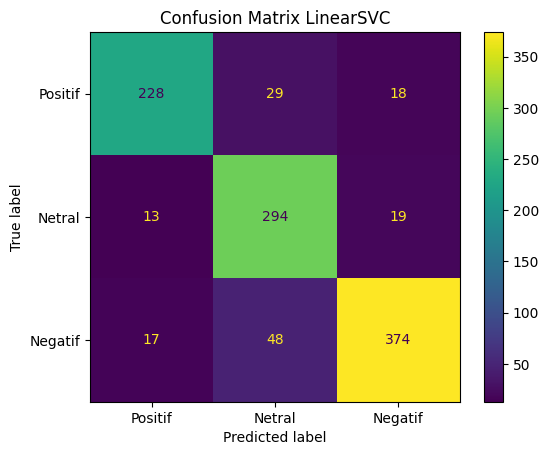

In [116]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_svc = confusion_matrix(
    y_test,
    y_pred_linearsvc,
    labels=["Positif", "Netral", "Negatif"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=["Positif", "Netral", "Negatif"]
)

disp.plot()
plt.title("Confusion Matrix LinearSVC")
plt.show()

<Figure size 640x480 with 0 Axes>

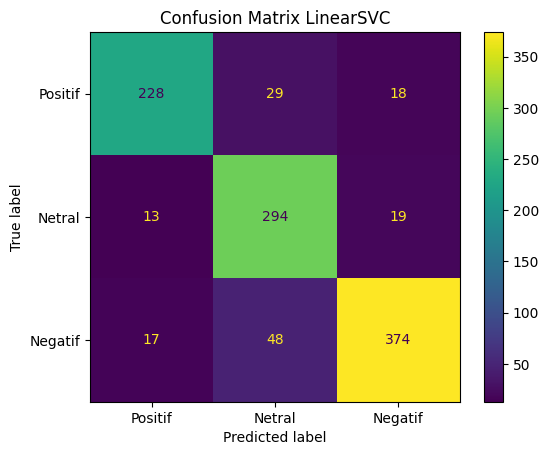

In [117]:
plt.figure()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=["Positif", "Netral", "Negatif"]
)

disp.plot()
plt.title("Confusion Matrix LinearSVC")

plt.savefig(
    f"{folder_path}/confusion_matrix_LinearSVC.png",
    bbox_inches="tight"
)

plt.show()

In [118]:
akurasi_nb = accuracy_score(y_test, y_pred_naivebayes)
precision_nb = precision_score(
    y_test, y_pred_naivebayes, average="weighted"
)
recall_nb = recall_score(
    y_test, y_pred_naivebayes, average="weighted"
)
f1_nb = f1_score(
    y_test, y_pred_naivebayes, average="weighted"
)

print("Evaluasi Multinomial Naive Bayes")
print(f"Accuracy  : {akurasi_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1-Score  : {f1_nb:.4f}")

Evaluasi Multinomial Naive Bayes
Accuracy  : 0.6962
Precision : 0.7376
Recall    : 0.6962
F1-Score  : 0.6805


In [119]:
print(classification_report(
    y_test,
    y_pred_naivebayes,
    labels=["Positif", "Netral", "Negatif"]
))

              precision    recall  f1-score   support

     Positif       0.78      0.62      0.69       275
      Netral       0.84      0.43      0.57       326
     Negatif       0.63      0.94      0.75       439

    accuracy                           0.70      1040
   macro avg       0.75      0.66      0.67      1040
weighted avg       0.74      0.70      0.68      1040



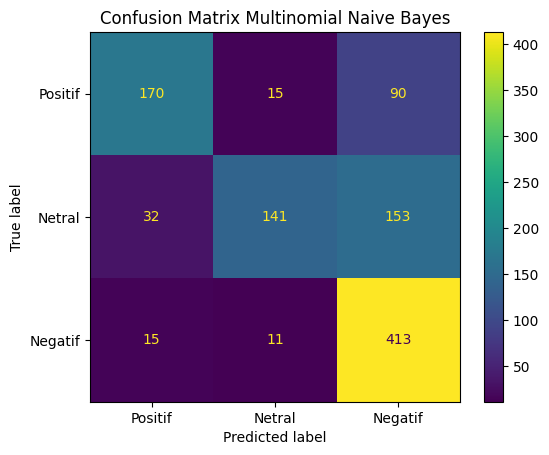

In [120]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_naivebayes,
    labels=["Positif", "Netral", "Negatif"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Positif", "Netral", "Negatif"]
)

disp.plot()
plt.title("Confusion Matrix Multinomial Naive Bayes")
plt.show()

<Figure size 640x480 with 0 Axes>

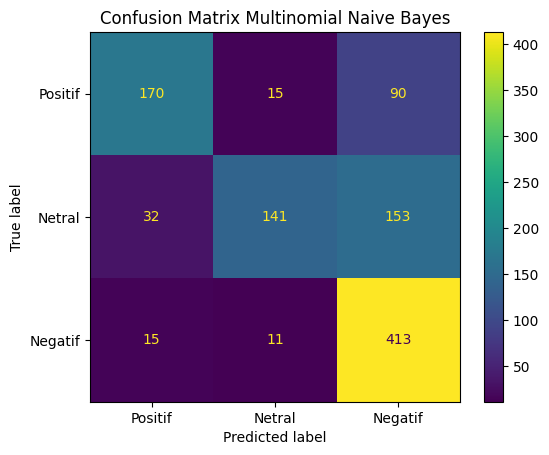

In [121]:
plt.figure()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Positif", "Netral", "Negatif"]
)

disp.plot()
plt.title("Confusion Matrix Multinomial Naive Bayes")

plt.savefig(
    f"{folder_path}/confusion_matrix_Multinomial_Naive_Bayes.png",
    bbox_inches="tight"
)

plt.show()

# 8.Perbandingan Performa Model

In [122]:
hasil_perbandingan = pd.DataFrame({
    "Model": [
        "LinearSVC",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linearsvc),
        accuracy_score(y_test, y_pred_naivebayes)
    ],
    "Precision": [
        precision_score(
            y_test, y_pred_linearsvc, average="weighted"
        ),
        precision_score(
            y_test, y_pred_naivebayes, average="weighted"
        )
    ],
    "Recall": [
        recall_score(
            y_test, y_pred_linearsvc, average="weighted"
        ),
        recall_score(
            y_test, y_pred_naivebayes, average="weighted"
        )
    ],
    "F1-Score": [
        f1_score(
            y_test, y_pred_linearsvc, average="weighted"
        ),
        f1_score(
            y_test, y_pred_naivebayes, average="weighted"
        )
    ]
})

hasil_perbandingan

,Model,Accuracy,Precision,Recall,F1-Score
0,LinearSVC,0.861538,0.866194,0.861538,0.862126
1,Multinomial Naive Bayes,0.696154,0.737563,0.696154,0.680452


In [123]:
hasil_perbandingan.to_csv(
    f"{folder_path}/perbandingan_performa_model.csv",
    index=False
)

print("Tabel perbandingan performa model berhasil disimpan.")

Tabel perbandingan performa model berhasil disimpan.


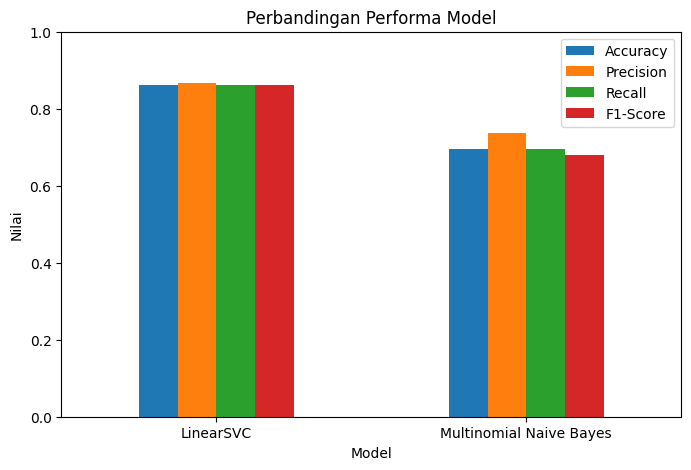

In [124]:
hasil_perbandingan.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Nilai")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

<Figure size 800x500 with 0 Axes>

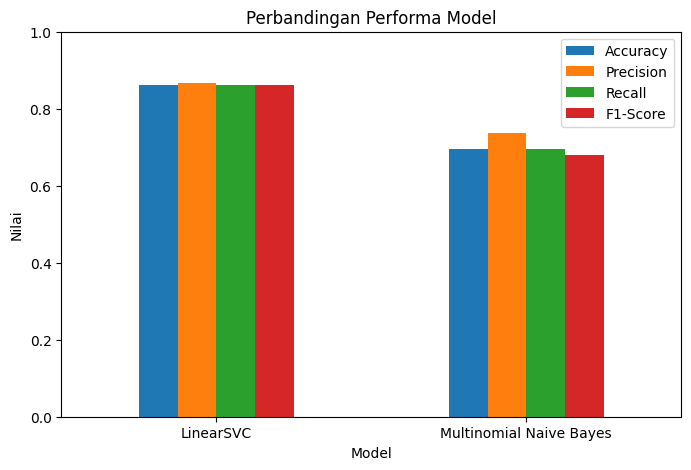

In [131]:
plt.figure(figsize=(8, 5))

hasil_perbandingan.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Nilai")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()

plt.savefig(
    f"{folder_path}/perbandingan_performa_model.png",
    bbox_inches="tight"
)

plt.show()

In [126]:
hasil_perbandingan.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,LinearSVC,0.8615,0.8662,0.8615,0.8621
1,Multinomial Naive Bayes,0.6962,0.7376,0.6962,0.6805


In [127]:
distribusi_label = df["label"].value_counts()

print("Distribusi Label Sentimen:")
print(distribusi_label)

Distribusi Label Sentimen:
label
Negatif    2196
Netral     1629
Positif    1374
Name: count, dtype: int64


In [128]:
persentase_label = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Persentase Label Sentimen:")
print(persentase_label)

Persentase Label Sentimen:
label
Negatif    42.24
Netral     31.33
Positif    26.43
Name: proportion, dtype: float64


In [129]:
tabel_distribusi = pd.DataFrame({
    "Sentimen": distribusi_label.index,
    "Jumlah": distribusi_label.values,
    "Persentase (%)": persentase_label.values
})

tabel_distribusi

,Sentimen,Jumlah,Persentase (%)
0,Negatif,2196,42.24
1,Netral,1629,31.33
2,Positif,1374,26.43


In [130]:
tabel_distribusi.to_csv(
    f"{folder_path}/distribusi_label_sentimen.csv",
    index=False
)

print("Distribusi label berhasil disimpan.")

Distribusi label berhasil disimpan.
